In [ ]:
# ============================================================
# 2.1 DESCRIPCIÓN DEL DATASET
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Cargar dataset original
df_raw = pd.read_csv("support2.csv")

print("=" * 60)
print("2.1 DESCRIPCIÓN DEL DATASET")
print("=" * 60)

print(f"Número de pacientes: {df_raw.shape[0]}")
print(f"Número de variables: {df_raw.shape[1]}")

print("\nPrimeras 5 observaciones:")
print(df_raw.head())

print("\nVariables disponibles:")
print(df_raw.columns.tolist())

print("\nTipos de datos:")
print(df_raw.dtypes)

print("\nInformación general:")
df_raw.info()

print("\nEstadísticas descriptivas:")
print(df_raw.describe().T.round(2))

print("\nVariable objetivo hospdead:")
print(df_raw["hospdead"].value_counts(dropna=False).sort_index())

2.1 DESCRIPCIÓN DEL DATASET
Número de pacientes: 9105
Número de variables: 47

Primeras 5 observaciones:
        age  death     sex  hospdead  slos  d.time            dzgroup  \
1  62.84998      0    male         0     5    2029        Lung Cancer   
2  60.33899      1  female         1     4       4          Cirrhosis   
3  52.74698      1  female         0    17      47          Cirrhosis   
4  42.38498      1  female         0     3     133        Lung Cancer   
5  79.88495      0  female         0    16    2029  ARF/MOSF w/Sepsis   

              dzclass  num.co   edu  ...      crea    sod        ph  glucose  \
1              Cancer       0  11.0  ...  1.199951  141.0  7.459961      NaN   
2  COPD/CHF/Cirrhosis       2  12.0  ...  5.500000  132.0  7.250000      NaN   
3  COPD/CHF/Cirrhosis       2  12.0  ...  2.000000  134.0  7.459961      NaN   
4              Cancer       2  11.0  ...  0.799927  139.0       NaN      NaN   
5            ARF/MOSF       1   NaN  ...  0.799927  143.

2.2 ANÁLISIS DE VALORES FALTANTES

Valores faltantes por variable:
         Faltantes  Porcentaje (%)
adlp          5641           61.95
urine         4862           53.40
glucose       4500           49.42
bun           4352           47.80
totmcst       3475           38.17
alb           3372           37.03
income        2982           32.75
adls          2867           31.49
bili          2601           28.57
pafi          2325           25.54
ph            2284           25.09
prg2m         1649           18.11
edu           1634           17.95
prg6m         1633           17.94
sfdm2         1400           15.38
totcst         888            9.75
wblc           212            2.33
charges        172            1.89
avtisst         82            0.90
crea            67            0.74
race            42            0.46
dnrday          30            0.33
dnr             30            0.33
scoma            1            0.01
sps              1            0.01
meanbp           1     

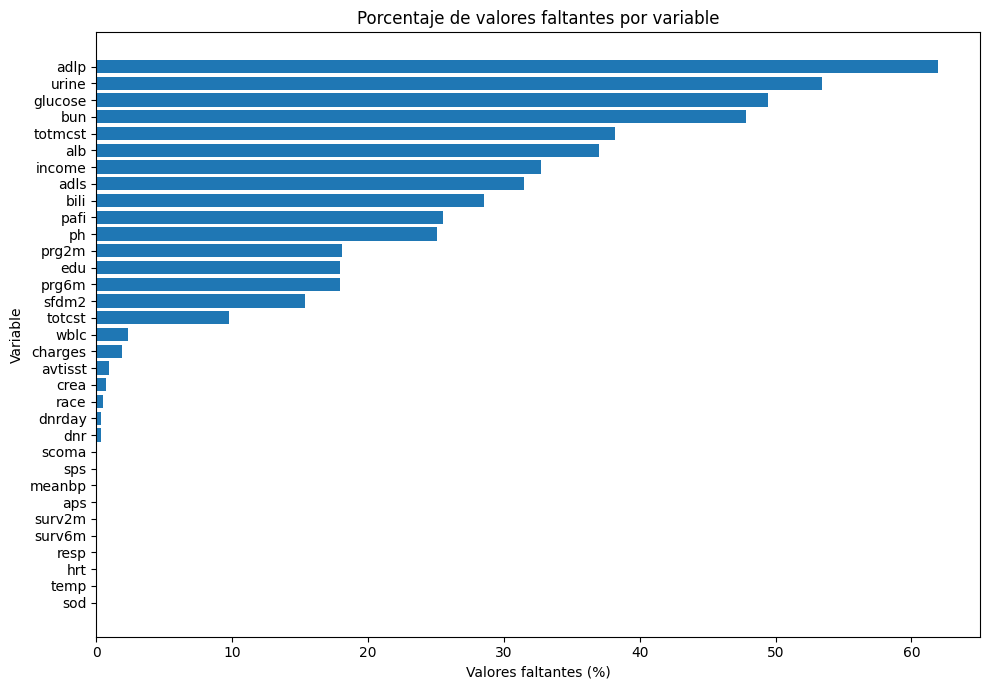

In [ ]:
# ============================================================
# 2.2 ANÁLISIS DE VALORES FALTANTES
# ============================================================

print("=" * 60)
print("2.2 ANÁLISIS DE VALORES FALTANTES")
print("=" * 60)

missing = pd.DataFrame({
    "Faltantes": df_raw.isnull().sum(),
    "Porcentaje (%)": df_raw.isnull().mean() * 100
})

# Mostrar solo variables con datos faltantes
missing = missing[
    missing["Faltantes"] > 0
].sort_values(
    "Porcentaje (%)",
    ascending=False
)

missing["Porcentaje (%)"] = missing["Porcentaje (%)"].round(2)

print("\nValores faltantes por variable:")
print(missing)

print(
    "\nNúmero de variables con valores faltantes:",
    len(missing)
)

# Gráfico
plt.figure(figsize=(10, 7))

plt.barh(
    missing.index,
    missing["Porcentaje (%)"]
)

plt.xlabel("Valores faltantes (%)")
plt.ylabel("Variable")
plt.title("Porcentaje de valores faltantes por variable")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 2.3 IDENTIFICACIÓN Y PREVENCIÓN DE DATA LEAKAGE
# ============================================================

print("=" * 60)
print("2.3 DATA LEAKAGE")
print("=" * 60)

leakage_cols = [
    "sps",
    "aps",
    "surv2m",
    "surv6m",
    "prg2m",
    "prg6m",
    "dnr",
    "dnrday"
]

tabla_leakage = pd.DataFrame({
    "Variable": leakage_cols,
    "Presente_en_dataset": [
        col in df_raw.columns
        for col in leakage_cols
    ]
})

print("\nVariables identificadas con riesgo de leakage:")
print(tabla_leakage)

# Crear copia para el resto del EDA
# El dataset original se conserva en df_raw
columnas_eliminar = [
    col for col in leakage_cols
    if col in df_raw.columns
]

df_eda = df_raw.drop(
    columns=columnas_eliminar
).copy()

print("\nDimensiones originales:")
print(df_raw.shape)

print("\nDimensiones después de excluir leakage:")
print(df_eda.shape)

print("\nVariables excluidas:")
print(columnas_eliminar)

2.3 DATA LEAKAGE

Variables identificadas con riesgo de leakage:
  Variable  Presente_en_dataset
0      sps                 True
1      aps                 True
2   surv2m                 True
3   surv6m                 True
4    prg2m                 True
5    prg6m                 True
6      dnr                 True
7   dnrday                 True

Dimensiones originales:
(9105, 47)

Dimensiones después de excluir leakage:
(9105, 39)

Variables excluidas:
['sps', 'aps', 'surv2m', 'surv6m', 'prg2m', 'prg6m', 'dnr', 'dnrday']


2.4 DISTRIBUCIÓN DE LA VARIABLE OBJETIVO

Distribución de hospdead:
          Frecuencia  Porcentaje (%)
hospdead                            
0               6745           74.08
1               2360           25.92


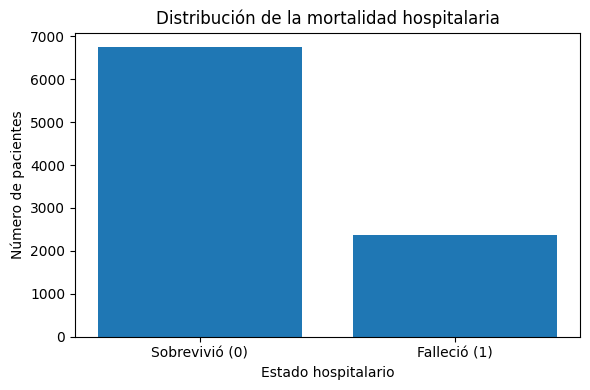

In [ ]:
# ============================================================
# 2.4 DISTRIBUCIÓN DE LA VARIABLE OBJETIVO
# ============================================================

print("=" * 60)
print("2.4 DISTRIBUCIÓN DE LA VARIABLE OBJETIVO")
print("=" * 60)

conteo = (
    df_eda["hospdead"]
    .value_counts()
    .sort_index()
)

porcentaje = (
    df_eda["hospdead"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

tabla_clases = pd.DataFrame({
    "Frecuencia": conteo,
    "Porcentaje (%)": porcentaje.round(2)
})

print("\nDistribución de hospdead:")
print(tabla_clases)

plt.figure(figsize=(6, 4))

plt.bar(
    ["Sobrevivió (0)", "Falleció (1)"],
    conteo.values
)

plt.xlabel("Estado hospitalario")
plt.ylabel("Número de pacientes")
plt.title("Distribución de la mortalidad hospitalaria")

plt.tight_layout()
plt.show()

2.5 VARIABLES FISIOLÓGICAS SEGÚN MORTALIDAD

Resumen fisiológico según mortalidad:
         meanbp                 wblc                  hrt                \
           mean median    std   mean median   std    mean median    std   
hospdead                                                                  
0         85.98   79.0  26.38  11.96   10.3  8.99   95.37   96.0  29.79   
1         80.45   73.0  30.75  13.43   11.7  9.92  102.25  108.0  35.66   

           resp  ...    ph glucose                  bun                \
           mean  ...   std    mean median    std   mean median    std   
hospdead         ...                                                    
0         23.21  ...  0.08  159.25  133.0  88.06  31.78   23.0  26.34   
1         23.67  ...  0.09  161.72  139.0  89.39  34.04   24.0  28.04   

            urine                   
             mean  median      std  
hospdead                            
0         2205.59  1975.0  1450.38  
1         2149.76  1937.0  

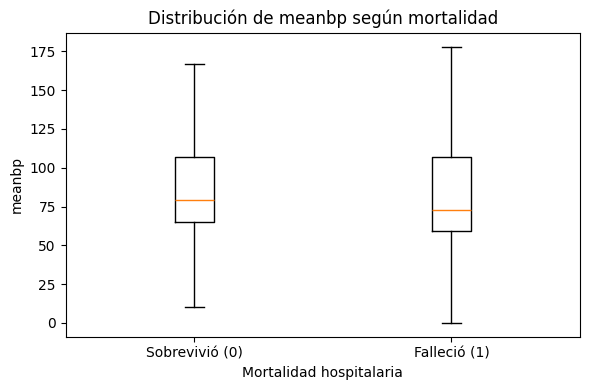

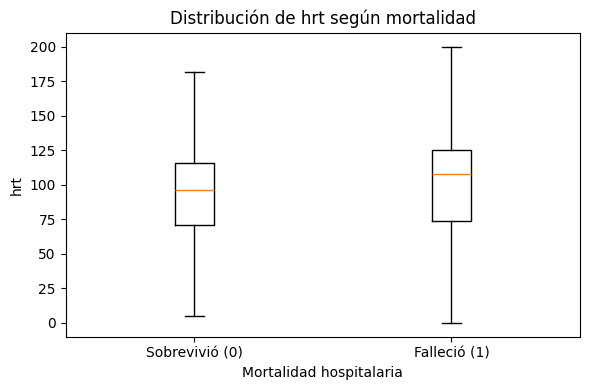

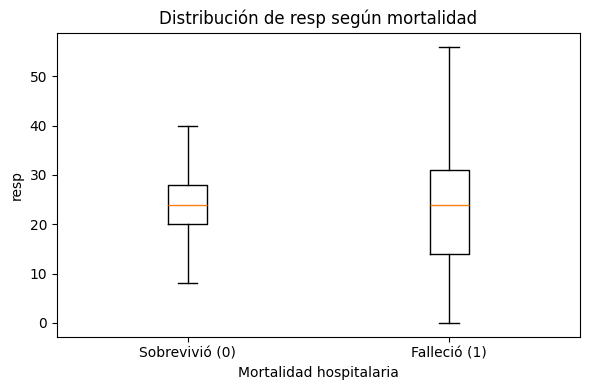

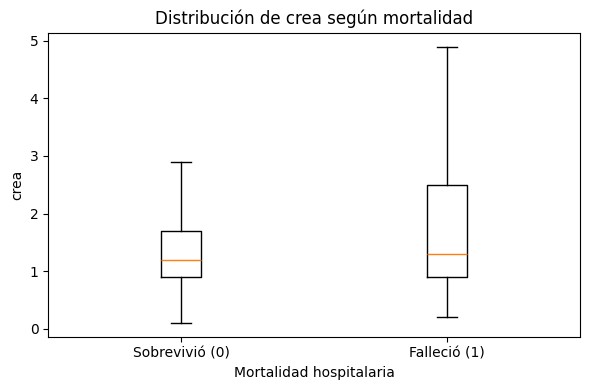

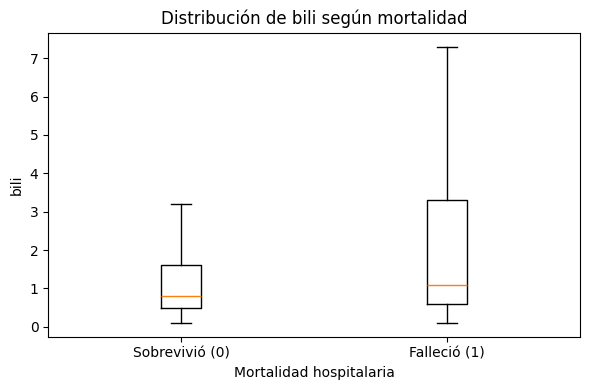

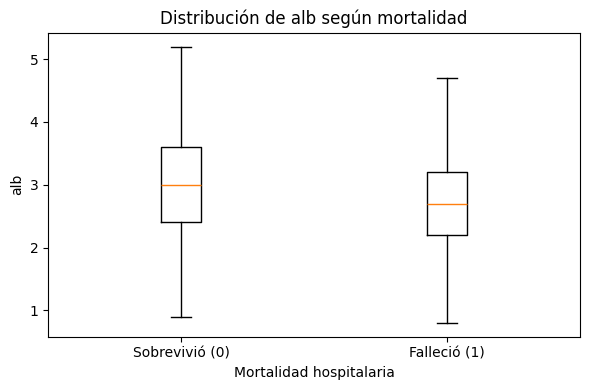

In [ ]:
# ============================================================
# 2.5 VARIABLES FISIOLÓGICAS SEGÚN MORTALIDAD
# ============================================================

print("=" * 60)
print("2.5 VARIABLES FISIOLÓGICAS SEGÚN MORTALIDAD")
print("=" * 60)

fisiologicas = [
    "meanbp",
    "wblc",
    "hrt",
    "resp",
    "temp",
    "pafi",
    "alb",
    "bili",
    "crea",
    "sod",
    "ph",
    "glucose",
    "bun",
    "urine"
]

# Mantener solo las columnas que realmente existan
fisiologicas = [
    col for col in fisiologicas
    if col in df_eda.columns
]

# Media, mediana y desviación estándar según mortalidad
resumen_fisio = (
    df_eda
    .groupby("hospdead")[fisiologicas]
    .agg(["mean", "median", "std"])
)

print("\nResumen fisiológico según mortalidad:")
print(resumen_fisio.round(2))


# ------------------------------------------------------------
# BOXPLOTS DE VARIABLES REPRESENTATIVAS
# ------------------------------------------------------------

vars_boxplot = [
    "meanbp",
    "hrt",
    "resp",
    "crea",
    "bili",
    "alb"
]

for col in vars_boxplot:

    if col not in df_eda.columns:
        continue

    sobrevivientes = df_eda.loc[
        df_eda["hospdead"] == 0,
        col
    ].dropna()

    fallecidos = df_eda.loc[
        df_eda["hospdead"] == 1,
        col
    ].dropna()

    plt.figure(figsize=(6, 4))

    plt.boxplot(
        [sobrevivientes, fallecidos],
        tick_labels=[
            "Sobrevivió (0)",
            "Falleció (1)"
        ],
        showfliers=False
    )

    plt.xlabel("Mortalidad hospitalaria")
    plt.ylabel(col)
    plt.title(
        f"Distribución de {col} según mortalidad"
    )

    plt.tight_layout()
    plt.show()

2.6 ANÁLISIS DE CORRELACIÓN

Correlación de las variables con hospdead:
scoma      0.380
bili       0.168
alb       -0.143
pafi      -0.104
crea       0.099
hrt        0.095
meanbp    -0.088
num.co    -0.078
temp       0.070
wblc       0.070
age        0.039
ph        -0.038
bun        0.037
sod        0.030
resp       0.021
urine     -0.017
glucose    0.012
Name: hospdead, dtype: float64


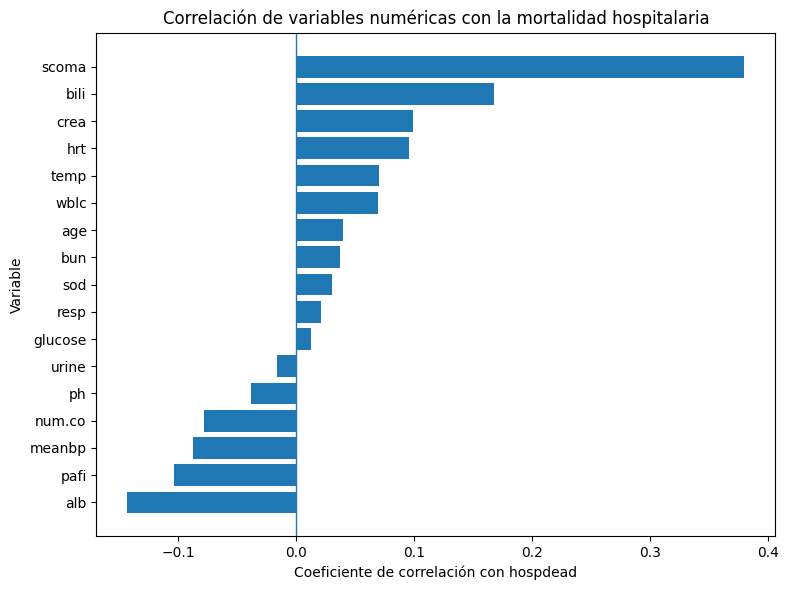

In [ ]:
# ============================================================
# 2.6 ANÁLISIS DE CORRELACIÓN CON LA VARIABLE OBJETIVO
# ============================================================

print("=" * 60)
print("2.6 ANÁLISIS DE CORRELACIÓN")
print("=" * 60)

variables_corr = [
    "age",
    "num.co",
    "scoma",
    "meanbp",
    "wblc",
    "hrt",
    "resp",
    "temp",
    "pafi",
    "alb",
    "bili",
    "crea",
    "sod",
    "ph",
    "glucose",
    "bun",
    "urine",
    "hospdead"
]

# Mantener únicamente las variables existentes
variables_corr = [
    col for col in variables_corr
    if col in df_eda.columns
]

# Matriz de correlación
corr = df_eda[variables_corr].corr()

# Correlación de cada variable con hospdead
corr_target = (
    corr["hospdead"]
    .drop("hospdead")
    .sort_values(key=abs, ascending=False)
)

print("\nCorrelación de las variables con hospdead:")
print(corr_target.round(3))


# ============================================================
# GRÁFICO
# ============================================================

# Ordenar para mostrar el gráfico de menor a mayor
corr_plot = corr_target.sort_values()

plt.figure(figsize=(8, 6))

plt.barh(
    corr_plot.index,
    corr_plot.values
)

plt.axvline(
    x=0,
    linewidth=1
)

plt.xlabel("Coeficiente de correlación con hospdead")
plt.ylabel("Variable")

plt.title(
    "Correlación de variables numéricas con la mortalidad hospitalaria"
)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 2.7 IDENTIFICACIÓN DE VALORES ATÍPICOS
# MÉTODO DEL RANGO INTERCUARTÍLICO (IQR)
# ============================================================

print("=" * 60)
print("2.7 IDENTIFICACIÓN DE OUTLIERS")
print("=" * 60)

resultados_outliers = []

for col in fisiologicas:

    datos = df_eda[col].dropna()

    # Cuartiles
    Q1 = datos.quantile(0.25)
    Q3 = datos.quantile(0.75)

    # Rango intercuartílico
    IQR = Q3 - Q1

    # Límites
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    # Identificar outliers
    outliers = (
        (datos < limite_inferior)
        |
        (datos > limite_superior)
    )

    numero_outliers = outliers.sum()

    porcentaje_outliers = (
        numero_outliers
        / len(datos)
        * 100
    )

    resultados_outliers.append([
        col,
        Q1,
        Q3,
        IQR,
        limite_inferior,
        limite_superior,
        numero_outliers,
        porcentaje_outliers
    ])


outliers_df = pd.DataFrame(
    resultados_outliers,
    columns=[
        "Variable",
        "Q1",
        "Q3",
        "IQR",
        "Límite inferior",
        "Límite superior",
        "N° outliers",
        "Porcentaje (%)"
    ]
)

outliers_df = (
    outliers_df
    .sort_values(
        "Porcentaje (%)",
        ascending=False
    )
)

print("\nOutliers identificados mediante IQR:")
print(outliers_df.round(2))

2.7 IDENTIFICACIÓN DE OUTLIERS

Outliers identificados mediante IQR:
   Variable       Q1       Q3      IQR  Límite inferior  Límite superior  \
7      bili     0.50     1.90     1.40            -1.60             4.00   
8      crea     0.90     1.90     1.00            -0.60             3.40   
11  glucose   103.00   188.00    85.00           -24.50           315.50   
12      bun    14.00    42.00    28.00           -28.00            84.00   
1      wblc     7.00    15.30     8.30            -5.45            27.75   
10       ph     7.38     7.47     0.09             7.25             7.60   
3      resp    18.00    28.00    10.00             3.00            43.00   
9       sod   134.00   141.00     7.00           123.50           151.50   
13    urine  1165.50  3000.00  1834.50         -1586.25          5751.75   
5      pafi   155.09   304.75   149.66           -69.39           529.23   
2       hrt    72.00   120.00    48.00             0.00           192.00   
6       alb     2.4

In [ ]:
# ============================================================
# 2.8 RESUMEN GENERAL DEL EDA
# ============================================================

print("=" * 60)
print("2.8 PRINCIPALES RESULTADOS DEL EDA")
print("=" * 60)

# ------------------------------------------------------------
# INFORMACIÓN GENERAL
# ------------------------------------------------------------

print("\n--- DATASET ---")

print(
    "Pacientes:",
    df_raw.shape[0]
)

print(
    "Variables originales:",
    df_raw.shape[1]
)

print(
    "Variables después de excluir leakage:",
    df_eda.shape[1]
)


# ------------------------------------------------------------
# VARIABLE OBJETIVO
# ------------------------------------------------------------

print("\n--- VARIABLE OBJETIVO ---")

print(tabla_clases)


# ------------------------------------------------------------
# MISSING VALUES
# ------------------------------------------------------------

print("\n--- VARIABLES CON MAYOR PORCENTAJE DE MISSING ---")

print(
    missing.head(10)
)


# ------------------------------------------------------------
# CORRELACIÓN CON HOSPDEAD
# ------------------------------------------------------------

print("\n--- MAYOR CORRELACIÓN ABSOLUTA CON HOSPDEAD ---")

print(
    corr_target.head(10)
    .round(3)
)


# ------------------------------------------------------------
# OUTLIERS
# ------------------------------------------------------------

print("\n--- VARIABLES CON MAYOR PORCENTAJE DE OUTLIERS ---")

print(
    outliers_df[
        [
            "Variable",
            "N° outliers",
            "Porcentaje (%)"
        ]
    ]
    .head(10)
    .round(2)
)


print("\nEDA COMPLETADO")

2.8 PRINCIPALES RESULTADOS DEL EDA

--- DATASET ---
Pacientes: 9105
Variables originales: 47
Variables después de excluir leakage: 39

--- VARIABLE OBJETIVO ---
          Frecuencia  Porcentaje (%)
hospdead                            
0               6745           74.08
1               2360           25.92

--- VARIABLES CON MAYOR PORCENTAJE DE MISSING ---
         Faltantes  Porcentaje (%)
adlp          5641           61.95
urine         4862           53.40
glucose       4500           49.42
bun           4352           47.80
totmcst       3475           38.17
alb           3372           37.03
income        2982           32.75
adls          2867           31.49
bili          2601           28.57
pafi          2325           25.54

--- MAYOR CORRELACIÓN ABSOLUTA CON HOSPDEAD ---
scoma     0.380
bili      0.168
alb      -0.143
pafi     -0.104
crea      0.099
hrt       0.095
meanbp   -0.088
num.co   -0.078
temp      0.070
wblc      0.070
Name: hospdead, dtype: float64

--- VARIABLES 